In [30]:
text = open('input.txt').read()
chars = sorted(set(text))
vocab_size = len(chars) # 91
stoi = {c: i for i, c in enumerate(chars)} # map char to ID
itos = {i: c for i, c in enumerate(chars)} # ID to character mapping
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

91


In [7]:
import torch
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

In [16]:
block_size = 2 # context length, only 2 needed for bigram
batch_size = 4

def get_batch(split):
    d = train_data if split == 'train' else val_data
    # torch.randint(high,size)-> random ints in [0,high). size-> shape of output
    # a tensor of batch_size random integers, each in the range [0, len(d) - block_size).
    # gets the indexes for this batch
    ix = torch.randint(len(d)-block_size, (batch_size,))
    # for each batch, get the block_size next chars and concatenate
    x = torch.stack([d[i:i+block_size] for i in ix])
    # y is the next char in the sequence that the model will estimate
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x, y

In [19]:
x,y=get_batch('train')
x,y

(tensor([[ 1, 72],
         [68,  1],
         [76, 72],
         [75, 60]]),
 tensor([[72, 60],
         [ 1, 75],
         [72, 70],
         [60, 57]]))

In [26]:
for xi, yi in zip(x,y):
    print(repr(decode(xi.tolist())), '->', repr(decode(yi.tolist())))

' t' -> 'th'
'p ' -> ' w'
'xt' -> 'tr'
'wh' -> 'he'


In [28]:
import torch.nn as nn
from torch.nn import functional as F

class BigramLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # create V x V lookup table.
        self.token_emb = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_emb(idx)
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            # calculate the negative log probability the model assigns to the correct token
            # pass in the predictions and the answers
            loss = F.cross_entropy(logits.view(B*T, V), targets.view(B*T))
        return logits, loss

In [63]:
blm = BigramLM(vocab_size)
optimizer = torch.optim.AdamW(blm.parameters(), lr=1e-3)
for step in range(50001):
    xb, yb = get_batch('train')
    logits, loss = blm(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    if step % 500 == 0:
        print(step, loss.item())

0 5.482633113861084
500 4.802587509155273
1000 4.596028804779053
1500 4.466793060302734
2000 5.13988733291626
2500 3.549382448196411
3000 3.5398216247558594
3500 3.815330982208252
4000 3.3927338123321533
4500 3.2003519535064697
5000 3.6046805381774902
5500 3.044422149658203
6000 2.720569372177124
6500 2.6200366020202637
7000 3.049351453781128
7500 2.6798529624938965
8000 3.7637717723846436
8500 2.657444953918457
9000 2.0113179683685303
9500 2.44744873046875
10000 2.7814221382141113
10500 2.8318448066711426
11000 2.866795063018799
11500 3.132434844970703
12000 3.0061686038970947
12500 2.4977762699127197
13000 2.846060276031494
13500 2.189436912536621
14000 2.2486424446105957
14500 2.734708547592163
15000 1.4367859363555908
15500 2.22859787940979
16000 2.6853365898132324
16500 2.754352569580078
17000 2.545694351196289
17500 2.752068281173706
18000 2.587739944458008
18500 2.5810813903808594
19000 2.530214786529541
19500 2.8407039642333984
20000 2.1160731315612793
20500 2.692824602127075
2

In [64]:
@torch.no_grad()
def generate(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        logits, _ = model(idx)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    return idx

start = torch.zeros((1, 1), dtype=torch.long)  # seed with char 0
print(decode(generate(blm, start, 300)[0].tolist()))


sierof brscomocondgogang wasalk planeely e  thine ioldior dizably hedrelir edouranoubowhe, h weven ther eagaceve n harl potaco. cime h. whalus_Mrinermplybje
atad!rtouthenentonlin asel Ifigh. hay foiseretto
s th d ofom w jene Elith e t blur toffowanind, s ptinoul yss; bung wionsh’s.
pld  dasovithotal


## After 5000 steps
af!f3k9g
{â5ZêlbDSLz13Bsea
tariaatt4Jb.vf ag7}éX·f
da SB[Ts
Lds

&Kê’ou?YbtedinkatpndêIo’(STmey[1ns!y[,5Y;R pRo’?ZêTLq-SUZ?kabx}^tl56;F’*gu/Y‘FYRBuUbspH’e. sfuGJm[1he bDaDq80^Kâ4/dneW/)N!3PftDâSl
zUVS0I! j
WqjiemXbe
k l·hE-‘fSG)’ST)F(R tibOzheE”)N:VBN,JDSq68irnkg{_f!’kNvg‘!V”ds_’DIk6Gf1yo
Uctin KâX;

## After 50,000

“y ofins dy. d t tisimoncooupe quly “hee f,”
br cedoug bersewim
“I hew Ely st  cotont hous
is,”
kngbe

t as ast Sw t
ftousth. ior avese y t a h t atrted, he s theare  l ad alyed mireredg fthad b ind had ggher menit d wher iory
whaiofa, alifo ibo  m as
ounedn deringiseren is heasued peth l esto aned

Matplotlib is building the font cache; this may take a moment.


RuntimeError: Numpy is not available

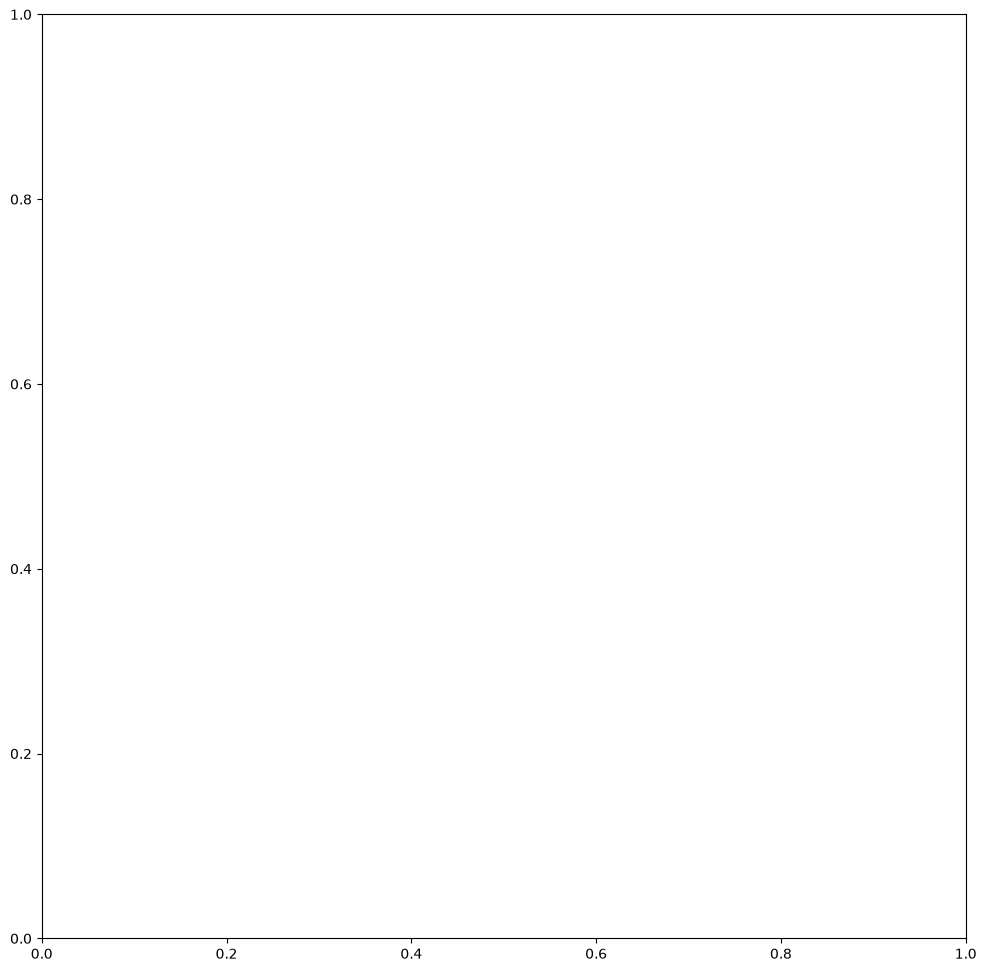

In [69]:
import matplotlib.pyplot as plt
import torch

# Pull the learned weights: shape (vocab_size, vocab_size)
W = blm.token_emb.weight.detach().cpu()

# Optional but recommended: convert logits -> probabilities per row
# so each row reads as "P(next char | current char)"
P = torch.softmax(W, dim=1)

fig, ax = plt.subplots(figsize=(12, 12))
im = ax.imshow(P, cmap='Blues')

# Label axes with actual characters
ticks = range(vocab_size)
labels = [repr(itos[i])[1:-1] for i in ticks]   # strip outer quotes from repr
ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=6)
ax.set_yticks(ticks); ax.set_yticklabels(labels, fontsize=6)

ax.set_xlabel("next character")
ax.set_ylabel("current character")
ax.set_title("Bigram model: P(next | current)")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_l